In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from torchvision import models, transforms as T, datasets
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from PIL import Image

#### root data directory path

In [2]:
data_dir = r'C:\Users\CM\Desktop\My_Projects\ML Projects\Signature Recognition System\notebook\data'

#### the number of classes

In [3]:
class_name = os.listdir(data_dir)
len(class_name)

2

#### checking cuda availability

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:{}".format(device))

Device:cuda


#### Transforming the data

In [5]:
data_transform = T.Compose([
    T.Resize(size=(224, 224)),
    T.RandomRotation(degrees=(-20, +20)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#### Load Data with SafeImageFolder (handles corrupt images automatically)

In [6]:
class SafeImageFolder(ImageFolder):
    """ImageFolder that skips corrupt/unreadable images instead of crashing."""
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except Exception:
            return super().__getitem__(0)

data = SafeImageFolder(data_dir, transform=data_transform)
total_count = len(data)
print(f"Total images: {total_count}")
print(f"Classes: {data.classes}")

Total images: 6171
Classes: ['forged', 'real']


#### splitting the data

In [7]:
train_count = int(0.6 * total_count)
valid_count = int(0.3 * total_count)
test_count  = total_count - train_count - valid_count
train_data, val_data, test_data = torch.utils.data.random_split(
    data, (train_count, valid_count, test_count)
)

print("Train_data Size:", len(train_data))
print("Valid_data Size:", len(val_data))
print("Test_data  Size:", len(test_data))

Train_data Size: 3702
Valid_data Size: 1851
Test_data  Size: 618


#### Defining some Functions

In [8]:
def show_image(image, label, get_denormalize=True):
    image = image.permute(1, 2, 0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std  = torch.FloatTensor([0.229, 0.224, 0.225])
    if get_denormalize:
        image = image * std + mean
        image = np.clip(image, 0, 1)
    plt.imshow(image)
    plt.title(label)


def accuracy(y_pred, y_true):
    y_pred = F.softmax(y_pred, dim=1)
    top_p, top_class = y_pred.topk(1, dim=1)
    equals = top_class == y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))

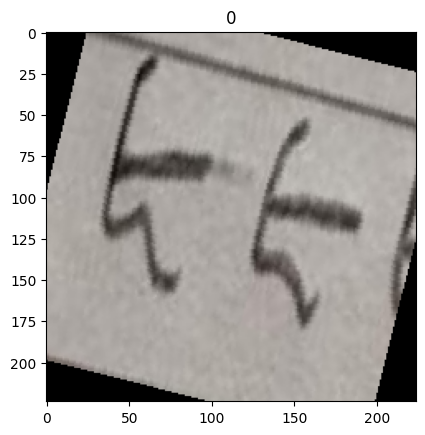

In [9]:
img, label = train_data[0]
show_image(img, label)

#### Data Loaders

In [ ]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
validationloader = DataLoader(val_data,   batch_size=32, shuffle=True)
testloader = DataLoader(test_data,  batch_size=32, shuffle=False)

print(f"Train batches:{len(trainloader)}  | Total: {len(trainloader.dataset)}")
print(f"Validation batches: {len(validationloader)} | Total: {len(validationloader.dataset)}")
print(f"Test batches: {len(testloader)}  | Total: {len(testloader.dataset)}")

Train batches:      116  | Total: 3702
Validation batches: 58 | Total: 1851
Test batches:       20  | Total: 618


* ### Working of CNN

1. Input Image
The CNN receives an input image that is preprocessed to ensure consistency in size and format.

2. Convolutional Layers
Filters (kernels) are applied to the input image to extract important features such as edges, textures, and shapes.  
Each filter produces a feature map highlighting specific patterns.

3. Pooling Layers
The generated feature maps are downsampled to reduce spatial dimensions and computational complexity while preserving important information.

4. Fully Connected Layers
The extracted features are flattened and passed through fully connected layers to learn high-level representations and perform classification.

5. Output
The CNN produces the final prediction, such as the class label of the input image.

* ### ResNet (Residual Network)

ResNet is a deep convolutional neural network designed for image recognition and processing tasks.  
It is well-known for enabling the training of very deep networks effectively without performance degradation.

The key idea behind ResNet is the introduction of **skip connections (residual connections)**, which allow the network to learn residual functions instead of directly learning mappings.

These connections help in:
- Reducing the vanishing gradient problem  
- Improving training of deep architectures  
- Allowing information to flow more easily through the network  

As a result, ResNet models achieve high performance in complex computer vision tasks.

<!-- 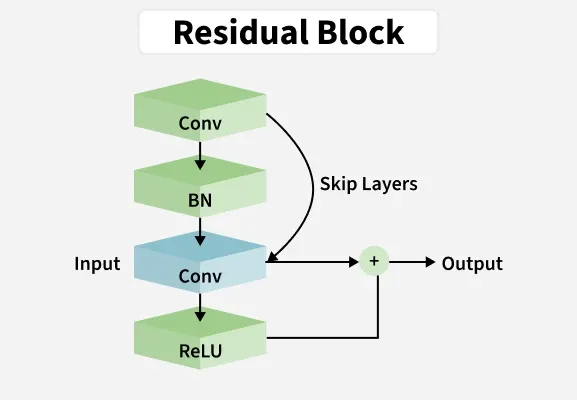 -->

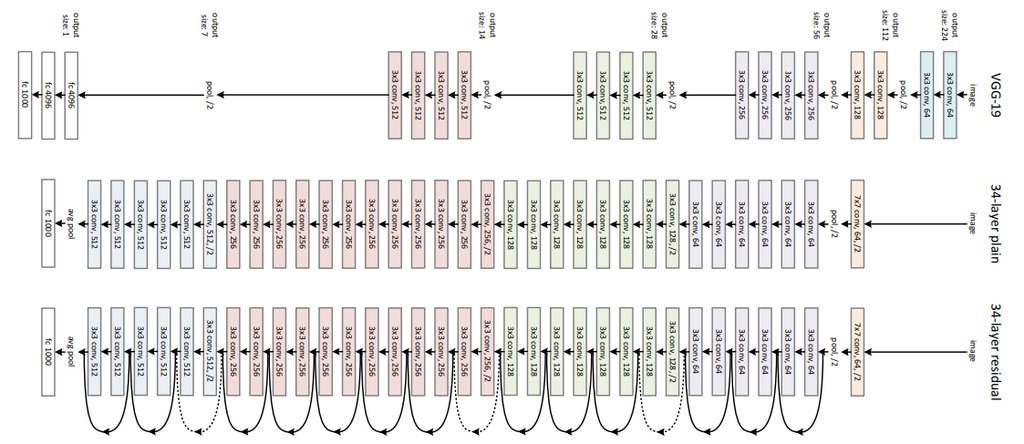

#### Model

In [11]:
model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

model.fc = nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(model.fc.in_features, len(class_name))
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

#### Training Function

In [12]:
def train(model, criterion, optimizer, train_dataloader, val_dataloader):
    total_train_loss = 0
    total_val_loss   = 0

    # --- Training phase ---
    model.train()
    with tqdm(train_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description('training')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs   = idxs.to(device, non_blocking=True)

            output = model(images)
            loss   = criterion(output, idxs)
            total_train_loss += loss.item()

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

    # --- Validation phase ---
    model.eval()
    with torch.no_grad():
        with tqdm(val_dataloader, unit='batch', leave=False) as pbar:
            pbar.set_description('validating')
            for images, idxs in pbar:
                images = images.to(device, non_blocking=True)
                idxs   = idxs.to(device, non_blocking=True)

                output = model(images)
                loss   = criterion(output, idxs)
                total_val_loss += loss.item()

    # --- Average loss per batch ---
    train_loss = total_train_loss / len(train_dataloader)
    val_loss   = total_val_loss   / len(val_dataloader)
    print(f'Train loss: {train_loss:.4f}  |  Val loss: {val_loss:.4f}')

#### Run Training

In [14]:
%%time
epochs = 5
for i in range(epochs):
    print(f"Epoch {i+1}/{epochs}")
    train(model, criterion, optimizer, trainloader, validationloader)

Epoch 1/5


Train loss: 0.3693  |  Val loss: 0.4170
Epoch 2/5


Train loss: 0.2841  |  Val loss: 0.3419
Epoch 3/5


Train loss: 0.2147  |  Val loss: 0.3321
Epoch 4/5


Train loss: 0.1478  |  Val loss: 0.3578
Epoch 5/5


Train loss: 0.1106  |  Val loss: 0.3382
CPU times: total: 42min 3s
Wall time: 7min 20s


#### Model saving

In [16]:
pwd

'c:\\Users\\CM\\Desktop\\My_Projects\\ML Projects\\Signature Recognition System\\notebook'

In [17]:
Path = r'c:\\Users\\CM\\Desktop\\My_Projects\\ML Projects\\Signature Recognition System\\notebook\\model.pt'
torch.save(model, Path)

#### Loading torch model

In [18]:
# model class must be defined somewhere
model = torch.load(Path)
model.eval()

C:\Users\CM\AppData\Local\Temp\ipykernel_22384\1900442149.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(Path)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [21]:
#### Model Evaluation
def evaluate(model, criterion, optimizer, test_dataloader):
    total_test_loss = 0

    model.eval()
    with tqdm(test_dataloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)

            output = model(images)
            loss = criterion(output, idxs)
            total_test_loss += loss.item()

    test_acc = total_test_loss / len(val_data)
    print(f'Test loss: {test_acc :.4f} ')

In [22]:
evaluate(model, criterion, optimizer, testloader)

Test loss: 0.0030 


#### Prediction

In [23]:
label_name = data.classes
label_name

['forged', 'real']

In [37]:
from PIL import Image

# Load the image and preprocess it
image = Image.open(r"C:\Users\CM\Desktop\My_Projects\ML Projects\Signature Recognition System\notebook\data\forged\lid_1644037246825_1_JPEG_20220205_100032.jpg\1__lid_1644037246825_1_JPEG_20220205_100032.jpg.jpg")
preprocess = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.Grayscale(3),
    transforms. ToTensor()
])

image = preprocess(image)
image = image[:3]

# Convert the image to a PyTorch tensor and send it to the device
image = image.unsqueeze(0).to(device)

# Make the prediction
with torch.no_grad():
    logits = model(image)
    probs = torch.softmax(logits, dim=1)
    pred_label = torch.argmax(probs, dim=1)

# Print the prediction
print(f'Predicted label: {pred_label.item()}')

# Map the predicted label to the corresponding class name
predicted_class_name = label_name[pred_label.item()]

# Print the predicted class name
print(f'Predicted class name: {predicted_class_name}')

Predicted label: 0
Predicted class name: forged
